In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:


n, d = 2500, 75
rho = 0.2
q = 1.0
alpha = 1.0

gamma_c = 1 / (1 - rho)
print("critical gamma:", gamma_c)

def sample_halfsphere(n, d):
    Z = torch.randn(n, d)
    Z /= torch.norm(Z, dim=1, keepdim=True)
    signs = torch.sign(Z[:, 0]).unsqueeze(1)
    Z *= signs
    return Z

def get_ips(M):
    P = M @ M.T
    return P.fill_diagonal_(0)

def self_attention(X, gamma):
    n = X.shape[1]
    S = gamma * np.log(n) * (X @ X.T)
    A = torch.softmax(S, dim=-1)
    O = A @ X
    return O

for n in [500, 1000, 1500, 2000]:
    X = sample_halfsphere(n, d)
    before = get_ips(X)
    nn = torch.mean(before, dim=-1)
    
    gammas = np.linspace(0.2, 3.0, 60)
    ips = []
    for gamma in gammas:
        Y = self_attention(X, gamma)
        after = get_ips(Y / torch.norm(Y, dim=1, keepdim=True))
        near = torch.mean(after, dim=-1)
        diff = (1 - near) / (1 - nn)
        ips.append(diff.mean().item())

    plt.plot(gammas, ips)

critical gamma: 1.25


NameError: name 'torch' is not defined

In [286]:
before.mean(), after.mean()

(tensor(0.0090), tensor(0.0092))

In [198]:
before.std(), after.std()

(tensor(0.0999), tensor(4.7097e-05))

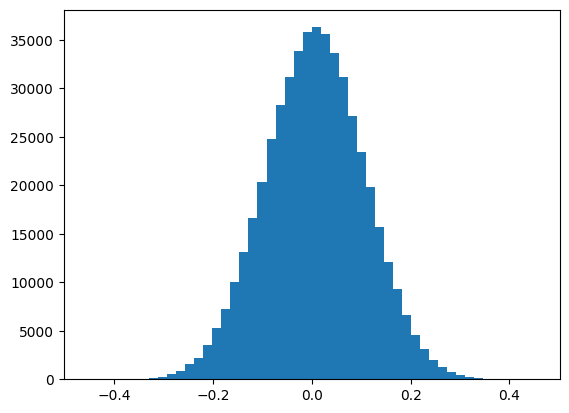

In [196]:
plt.hist(before, bins=50)
plt.show()

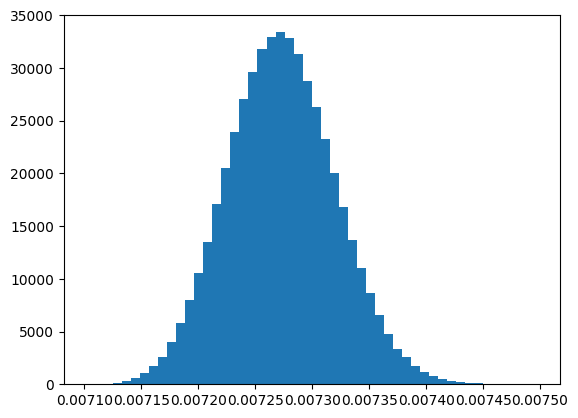

In [197]:
plt.hist(after, bins=50)
plt.show()

In [319]:
from mpl_toolkits.mplot3d import Axes3D

In [43]:
X = sample_halfsphere(50, 2)  

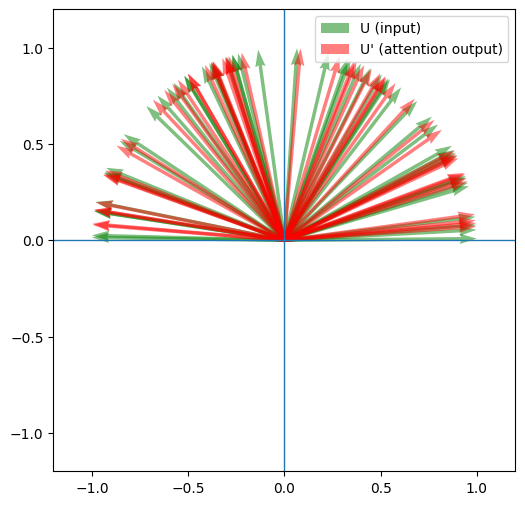

In [49]:
import torch
import matplotlib.pyplot as plt

        # (n, 2)
get_ips(X)

Y = self_attention(X, gamma=100)     # (n, 2)
Y = Y / torch.norm(Y, dim=1, keepdim=True)

fig, ax = plt.subplots(figsize=(6, 6))

# origins
origin_x = torch.zeros(X.size(0))

# ---- plot input vectors (green) ----
ax.quiver(
    origin_x, origin_x,
    X[:, 1], X[:, 0],
    angles='xy',
    scale_units='xy',
    scale=1,
    color='green',
    alpha=0.5,
    label='U (input)'
)

# ---- plot output vectors (blue) ----
ax.quiver(
    origin_x, origin_x,
    Y[:, 1], Y[:, 0],
    angles='xy',
    scale_units='xy',
    scale=1,
    color='red',
    alpha=0.5,
    label='U\' (attention output)'
)

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_aspect('equal')
ax.legend()
plt.show()

In [318]:
torch.diag(X @ Y.T).mean()

tensor(0.6291)

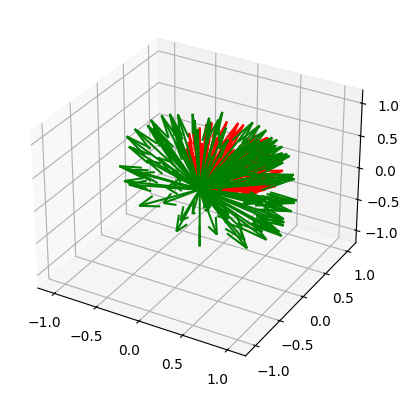

In [328]:
X = sample_halfsphere(100, 3)
get_ips(X)
Y = self_attention(X, gamma=1)
Y /= torch.norm(Y, dim=1, keepdim=True)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
origin = torch.zeros(X.size(0))

plt.quiver(
        origin, origin, origin,
        X[:, 1], 
        X[:, 0], 
        X[:, 2],
        color='green'
)

plt.quiver(
        origin, origin, origin,
        Y[:, 1], 
        Y[:, 0], 
        Y[:, 2],
        color='red'
)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

plt.show()

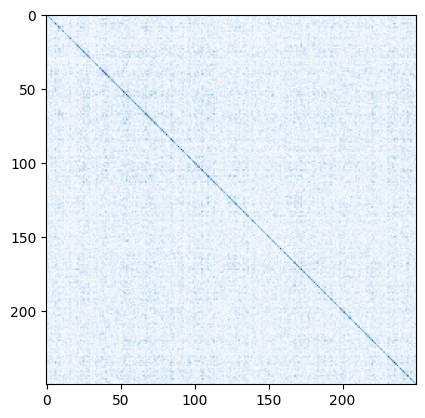

In [26]:
beta = np.sqrt(2)
n = 250
d = 100

betas = np.arange(0.2, 5, 0.1)

Wq = torch.randn(d, d)
Wk = torch.randn(d, d)

X = torch.randn(n, d)

Q = X @ Wq
K = X @ Wk

S = Q @ K.T

vs = []
for beta in {10e5}:
    sigma = beta**0.5 * (np.log(n))**0.25 / np.sqrt(d)
    Sc = sigma**2 * S
    A = torch.softmax(Sc, dim=1)
    A = torch.sort(A, dim=-1, descending=True).values
    v = (A[:, 0]).mean()
    #plt.hist(torch.flatten(Sc), bins = 50)
    Sigma = 1/(n - 1) * Sc.T @ Sc
    plt.imshow(torch.abs(Sigma), cmap='Blues')
    break
    vs.append(v)
    
    
#img = plt.imshow(A, cmap='Blues')

#cbar = plt.colorbar(img)
#cbar.set_label("Attention Weight")
plt.show()


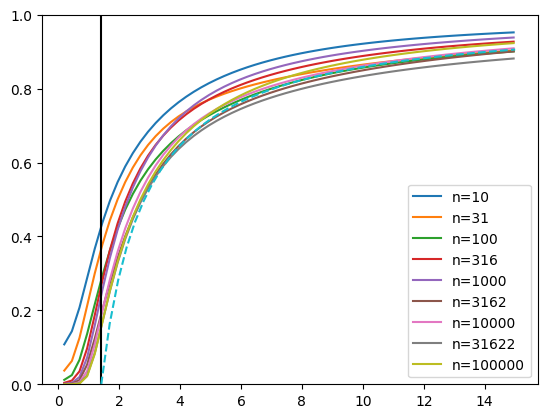

In [12]:
ns = np.arange(1, 5.5, 0.5)
ns = (10 ** ns).astype(int)
betas = np.arange(0.2, 15, 0.25)

for n in ns:
    S = np.log(n)**0.5 * torch.randn(100, n)
    vs = []
    for beta in betas:
        Sc = beta * S
        A = torch.softmax(Sc, dim=1)
        v = (A ** 2).sum(dim=1).mean()
        vs.append(v)
    plt.plot(betas , vs, label=f"n={n}")

plt.vlines(np.sqrt(2), 0, 10, colors='black')
xs = np.linspace(np.sqrt(2), 15)
plt.plot(xs, 1 - np.sqrt(2)/xs, '--')
plt.legend()
plt.ylim([0, 1])
plt.show()

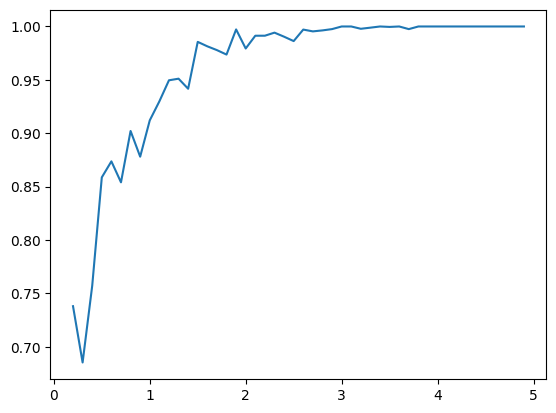

In [110]:
n = 10000
b = 1000
betas = np.arange(0.2, 5, 0.1)

def a_max(alpha, K=500):
    l = []
    for _ in range(1000):
        U = np.sort(np.random.exponential(1, size=K)) + np.log(np.arange(1, K+1))
    
        weights = np.exp(-(alpha/np.sqrt(2)) * U)
    
        l.append(1 / (1 + np.sum(weights)))

    return np.array(l).mean()

g = np.vectorize(lambda x: aba(x))
bs = g(betas)

plt.plot(betas, bs)

In [67]:
np.log(100000)

np.float64(11.512925464970229)

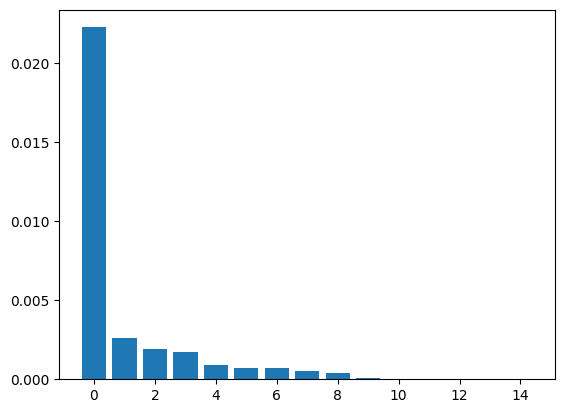

In [342]:
plt.bar(np.arange(15), torch.sort(A[8, :][:15], descending=True).values)
plt.show()

In [267]:
Sc.shape

torch.Size([5000, 5000])

In [145]:
hs = []
eps = 1e-15
gammas = np.arange(0.2, 4, 0.1)
for gamma in gammas:
    Sc = gamma * np.sqrt(np.log(n)) * S
    A = torch.softmax(Sc, dim=1)
    entropy = -(A * (A + eps).log()).sum(dim=1)
    m = entropy.mean()
    hs.append(m.item())

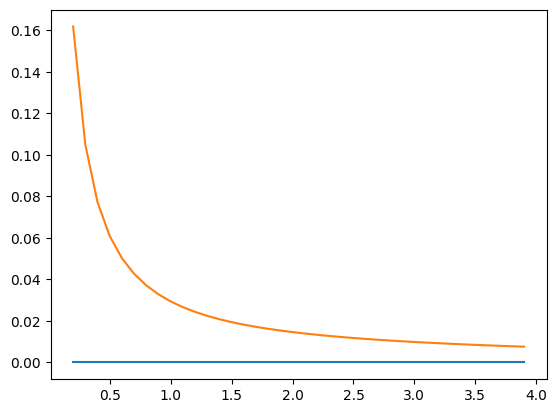

In [146]:
plt.plot(gammas, np.full_like(gammas, 0))
plt.plot(gammas, hs)

In [133]:
np.sqrt(np.log(n))

np.float64(2.8295525384149074)

In [245]:
n = 200
d = 500
rhos = np.arange(0, 1, 0.01)
gammas = np.arange(0, 10, 0.10)

mask = torch.triu(torch.ones((n, n), dtype=torch.bool), diagonal=1)

z0 = 1/np.sqrt(d) * torch.randn(d)
Z = 1/np.sqrt(d) * torch.randn(n, d)

Ls = np.zeros((len(rhos), len(gammas)))
for i, rho in enumerate(rhos):
    X = np.sqrt(rho) * z0 + np.sqrt(1 - rho) * Z
    U = X / torch.norm(X, dim=1, keepdim=True)
    before = get_ips(U)[mask]
    Lb = (1 - before)
    for j, gamma in enumerate(gammas):
        A = self_attention(U, gamma)
        Up = A / torch.norm(A, dim=1, keepdim=True)
        after = get_ips(Up)[mask]
        La = (1 - after)
        L = (La / Lb).mean()
        Ls[j, i] = L

(0.0, 10.0)

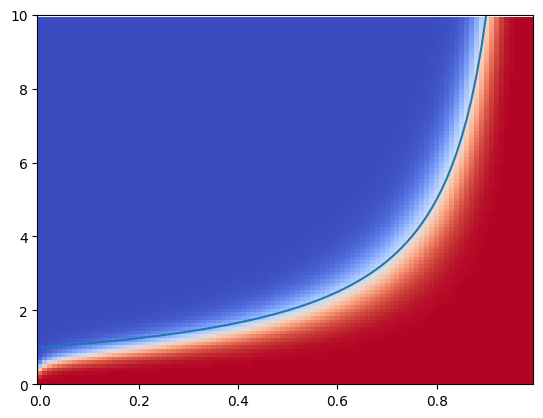

In [246]:
plt.pcolormesh(rhos, gammas, -Ls, cmap="coolwarm")
plt.plot(rhos[:-1], 1 / (1 - rhos[:-1]))
plt.ylim(0, 10)

In [264]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


fig, ax = plt.subplots()

line, = ax.plot([], [], lw=2)
ax.set_xlim(0, 10)

# set y-limits once (adjust if needed)
ax.set_ylim(np.min(Ls), np.max(Ls))

gammas = np.array(gammas)

def update(i):
    y = Ls[:, i]
    line.set_data(gammas, y)
    ax.set_title(f"slice index = {i}")
    return line,

anim = FuncAnimation(fig, update, frames=Ls.shape[1], interval=50)

plt.close(fig)

HTML(anim.to_jshtml())

In [66]:
exps = np.arange(1, 7)
ns = 10 ** exps
for n in ns:
    a = torch.zeros(n)
    a[0] = 1
    z = torch.softmax(a, dim=0)
    print(n, (z[0] / z[1]).item())

10 2.7182817459106445
100 2.7182817459106445
1000 2.7182817459106445
10000 2.7182817459106445
100000 2.7182817459106445
1000000 2.7182817459106445


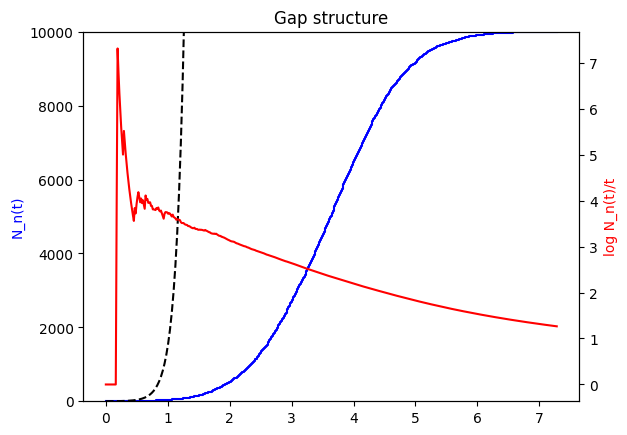

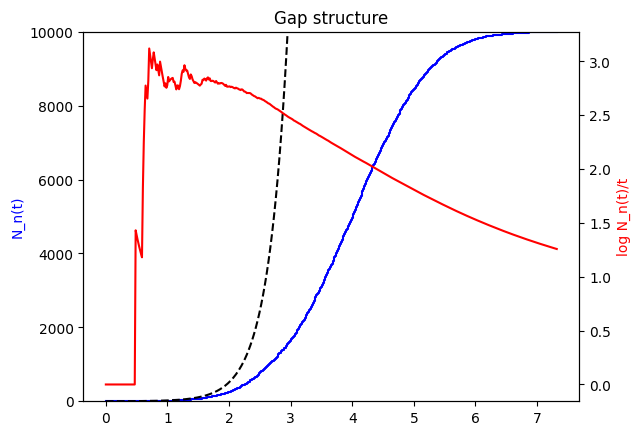

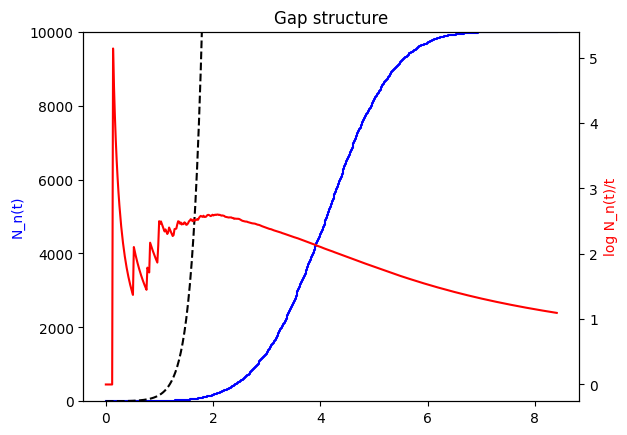

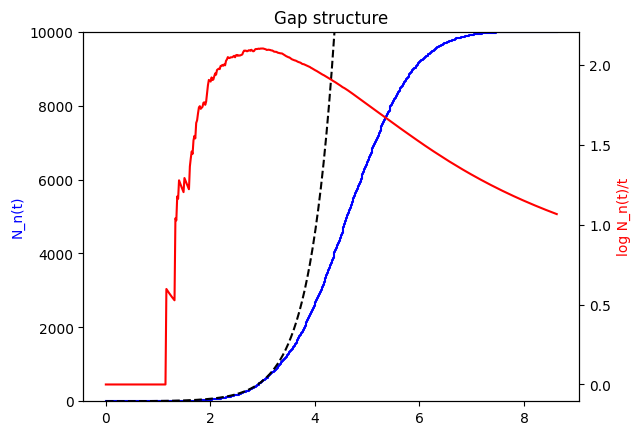

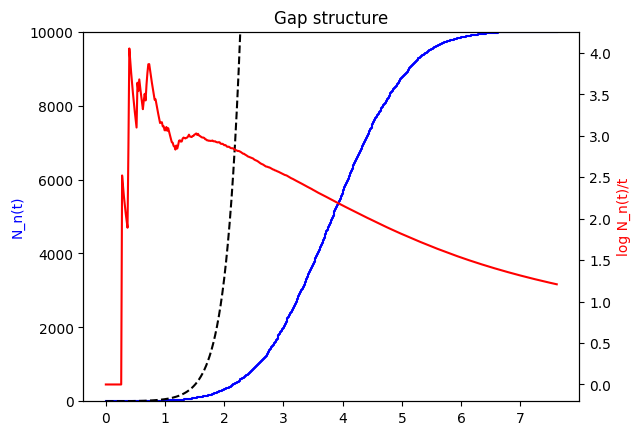

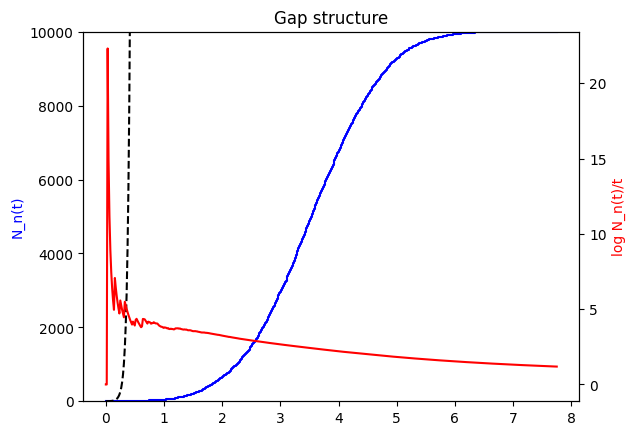

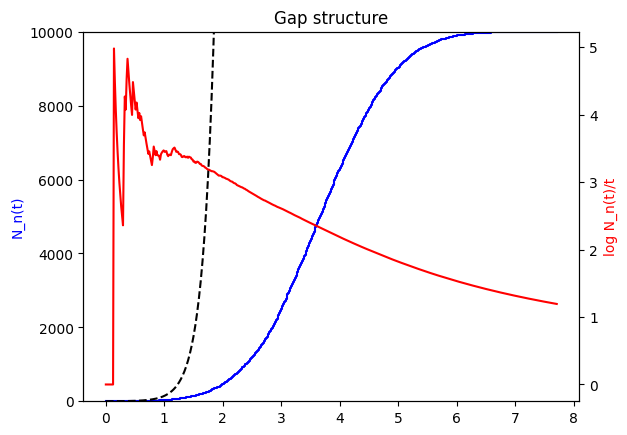

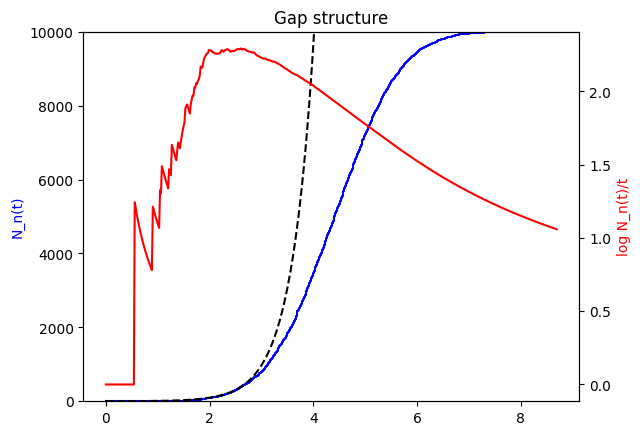

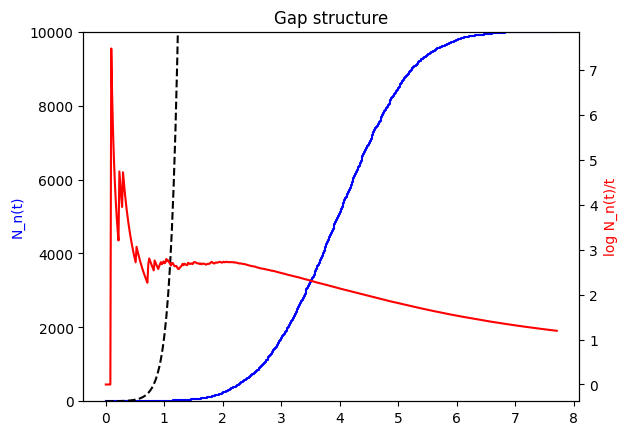

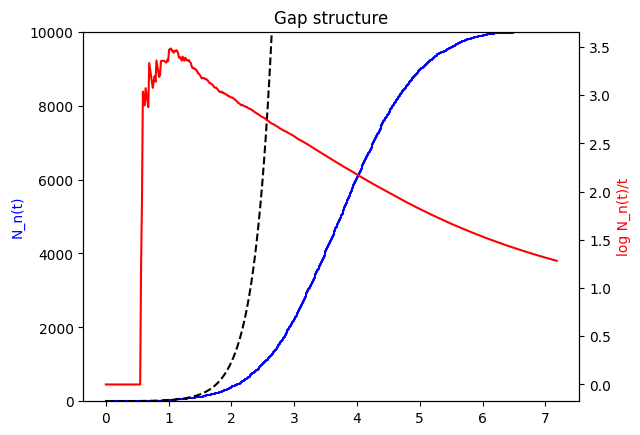

[0.89579272 0.51254878 0.73747903 0.33530444 0.63054128 1.39846738
 0.72331519 0.37372778 0.90620767 0.56228117]


In [4]:
# N(t) simulation

# 1. sample scores
ls = []
for _ in range(10):
    n = 10000
    z = np.random.randn(n)
    
    # 2. compute gaps
    z_star = np.max(z)
    Delta = z_star - z
    
    # 3. sort gaps (important for step function)
    Delta_sorted = np.sort(Delta)
    
    # 4. define t grid
    t = np.linspace(0, np.max(Delta_sorted), 500)
    
    # 5. compute N_n(t)
    N = np.searchsorted(Delta_sorted, t, side="right")
    
    fig, ax1 = plt.subplots()
    
    N_safe = np.maximum(N, 1)
    
    f = np.log(N_safe) / (t + 1e-8)
    
    Lambda = np.max(f)
    
    ax1.step(t, N, where="post", color="blue")
    ax1.set_ylabel("N_n(t)", color="blue")
    
    ax2 = ax1.twinx()
    ax2.plot(t, f, color="red")
    ax2.set_ylabel("log N_n(t)/t", color="red")
    
    y = f.max() * t
    
    ax1.plot(t, np.exp(Lambda * t), "--", color="black", label="Λ_n t")
    ax1.set_ylim(0, n)
    
    plt.title("Gap structure")
    plt.show()

    ls.append(np.log(Lambda) / np.log(np.log(n)))

print(np.array(ls))


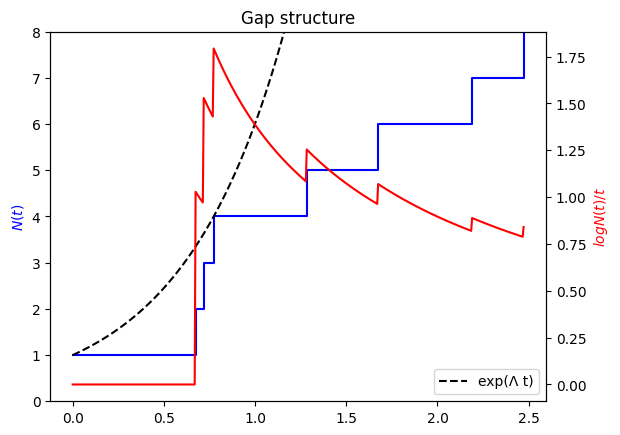

In [109]:
# N(t) simulation

# 1. sample scores
ls = []
for _ in range(1):
    n = 8
    z = np.random.randn(n)
    
    # 2. compute gaps
    z_star = np.max(z)
    Delta = z_star - z
    
    # 3. sort gaps (important for step function)
    Delta_sorted = np.sort(Delta)
    
    # 4. define t grid
    t = np.linspace(0, np.max(Delta_sorted), 500)
    
    # 5. compute N_n(t)
    N = np.searchsorted(Delta_sorted, t, side="right")
    
    fig, ax1 = plt.subplots()
    
    N_safe = np.maximum(N, 1)
    
    f = np.log(N_safe) / (t + 1e-8)
    
    Lambda = np.max(f)
    
    ax1.step(t, N, where="post", color="blue")
    ax1.set_ylabel("$N(t)$", color="blue")
    
    ax2 = ax1.twinx()
    ax2.plot(t, f, color="red")
    ax2.set_ylabel("$log N(t)/t$", color="red")
    
    y = f.max() * t
    
    ax1.plot(t, np.exp(Lambda * t), "--", color="black", label="exp(Λ t)")
    ax1.set_ylim(0, n)
    
    ax1.legend(loc='lower right')
    
    plt.title("Gap structure")
    plt.show()

    ls.append(np.log(Lambda) / np.log(np.log(n)))



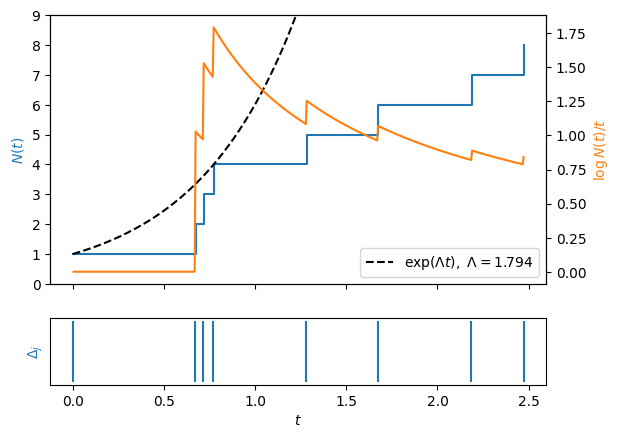

In [111]:
Lambda = np.nanmax(f)  # or your previously computed value

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

# --- N(t) ---
ax_top.step(t, N, where="post", color="#1f77b4")
ax_top.set_ylabel(r"$N(t)$", color="#1f77b4")

# --- exp envelope (critical lambda) ---
ax_top.plot(
    t,
    np.exp(Lambda * t),
    "--",
    color="black",
    label=rf"$\exp(\Lambda t),\ \Lambda={Lambda:.3f}$"
)

# --- right axis: log N(t)/t ---
ax_right = ax_top.twinx()

N_safe = np.maximum(N, 1)
f = np.log(N_safe) / (t + 1e-8)
f[0] = np.nan

ax_right.plot(t, f, color="#ff7f0e")
ax_right.set_ylabel(r"$\log N(t)/t$", color="#ff7f0e")

ax_top.set_ylim(0, len(z) + 1)

ax_top.legend(loc="lower right")

# --- bottom: gaps ---
ax_bottom.vlines(np.sort(Delta), 0, 1, color="#1f77b4", label="gaps")
ax_bottom.set_yticks([])
ax_bottom.set_xlabel(r"$t$")
ax_bottom.set_ylabel("$\\Delta_j$", color="#1f77b4")

plt.savefig("gap_plot.png", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_39875/3124553070.py:26: RuntimeWarning: divide by zero encountered in log
  Lambdas = Lambdas[np.log(Lambdas) <= 5]


np.float64(16.856067833438072)

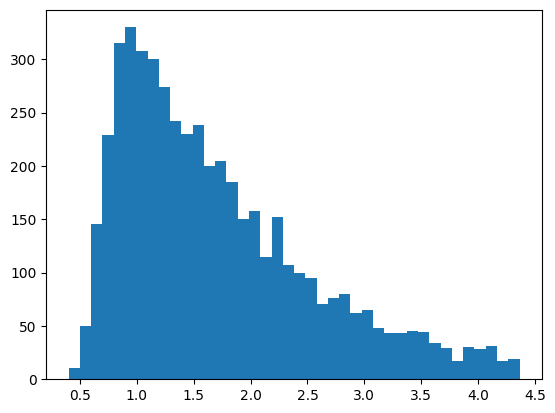

In [14]:
ns = np.arange(2.0, 2.5, 0.5 / 10)
ns = np.round(np.exp(np.exp(ns))).astype(int)

ls = []
for n in {3400}:
    trial = []
    maxs = []
    for _ in range(5000):
        z = np.random.normal(size=n)
        z_star = np.max(z)
        gaps = np.sort(z_star - z)

        #lo = int(0.05 * n)
        #hi = int(0.2 * n)
        lo = 0
        hi = n

        k = np.arange(1, n + 1)

            
        x = gaps
        y = np.log(k)
    
        # Lambda = np.max(y / (x + 1e-12))
        Lambdas = y / (x + 1e-12)
        Lambdas = Lambdas[np.log(Lambdas) <= 5]

        trial.append(Lambdas)
        maxs.append(Lambdas.max())

    ntrial = np.array(maxs)
    # ls.append(trial.mean())

#x = np.log(np.log(ns))
#y = np.log(ls)
#plt.plot(x, y, marker='o')

#np.polyfit(x, y, 1)

plt.hist(np.log(ntrial[ntrial < 80]), bins=40)
ntrial.std()

In [438]:
ntrial.std()

np.float64(0.4547202666290644)

0.6833258176780475


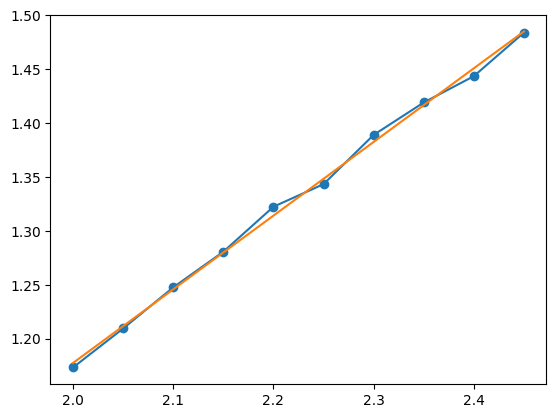

In [394]:
plt.plot(x, y, marker='o')
b1, b2 = np.polyfit(x, y, 1)

plt.plot(x, b1 * x + b2)

print(b1)

In [ ]:
xs = np.arange(1, 1000000)
onehalf = np.log(

In [ ]:
# N(t) simulation

# 1. sample scores
ls = []
for _ in range(10):
    n = 10000
    z = np.random.randn(n)
    
    # 2. compute gaps
    z_star = np.max(z)
    Delta = z_star - z
    
    # 3. sort gaps (important for step function)
    Delta_sorted = np.sort(Delta)
    
    # 4. define t grid
    t = np.linspace(0, np.max(Delta_sorted), 500)
    
    # 5. compute N_n(t)
    N = np.searchsorted(Delta_sorted, t, side="right")
    
    fig, ax1 = plt.subplots()
    
    N_safe = np.maximum(N, 1)
    
    f = np.log(N_safe) / (t + 1e-8)
    
    Lambda = np.max(f)
    
    ax1.step(t, N, where="post", color="blue")
    ax1.set_ylabel("N_n(t)", color="blue")
    
    ax2 = ax1.twinx()
    ax2.plot(t, f, color="red")
    ax2.set_ylabel("log N_n(t)/t", color="red")
    
    y = f.max() * t
    
    ax1.plot(t, np.exp(Lambda * t), "--", color="black", label="Λ_n t")
    ax1.set_ylim(0, n)
    
    plt.title("Gap structure")
    plt.show()

    ls.append(np.log(Lambda) / np.log(np.log(n)))

print(np.array(ls))


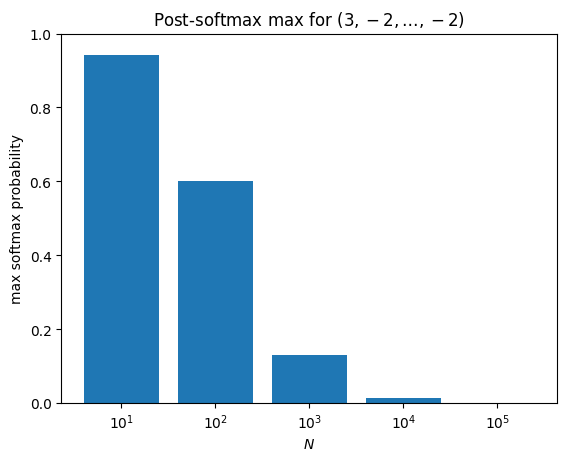

In [117]:
import numpy as np
import matplotlib.pyplot as plt

ns = np.arange(1, 6)
N = 10 ** ns

# post-softmax max probability
p_max = np.exp(3) / (np.exp(3) + (N - 1) * np.exp(-2))

plt.figure()

plt.bar([r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$"], p_max)

plt.ylabel(r"max softmax probability")
plt.xlabel(r"$N$")
plt.title(r"Post-softmax max for $(3, -2, \ldots, -2)$")

plt.ylim(0, 1)

plt.show()

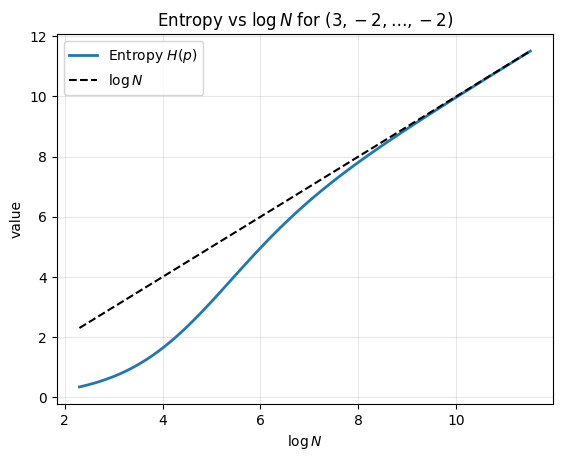

In [123]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    z = z - np.max(z)
    e = np.exp(z)
    return e / np.sum(e)

# smooth log-space sampling
ns = np.linspace(1, 5, 80)
N_list = (10 ** ns).astype(int)

H_list = []
logN_list = np.log(N_list)

for N in N_list:
    z = np.full(N, -2.0)
    z[0] = 3.0

    p = softmax(z)
    H = -np.sum(p * np.log(p + 1e-12))
    H_list.append(H)

H_list = np.array(H_list)

plt.figure()

# entropy curve
plt.plot(logN_list, H_list, color="#1f77b4", lw=2, label=r"Entropy $H(p)$")

# reference line log N
plt.plot(logN_list, logN_list, "--", color="black", label=r"$\log N$")

plt.xlabel(r"$\log N$")
plt.ylabel("value")
plt.title(r"Entropy vs $\log N$ for $(3, -2, \ldots, -2)$")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

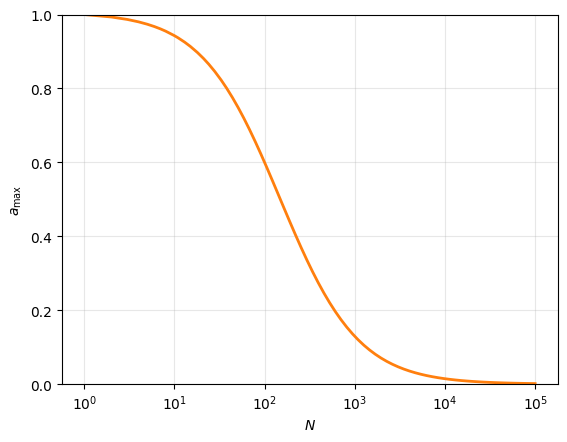

In [136]:
import numpy as np
import matplotlib.pyplot as plt

ns = np.linspace(0, 5, 80)
N_list = (10 ** ns).astype(int)

p_max = np.exp(3) / (np.exp(3) + (N_list - 1) * np.exp(-2))

plt.figure()

plt.plot(N_list, p_max, color="#ff7f0e", lw=2)

plt.xscale("log", base=10)

plt.xlabel(r"$N$")
plt.ylabel(r"$a_{\text{max}}$")

plt.tick_params(which='minor', bottom=False)

plt.grid(alpha=0.3)
plt.ylim([0, 1])

plt.show()

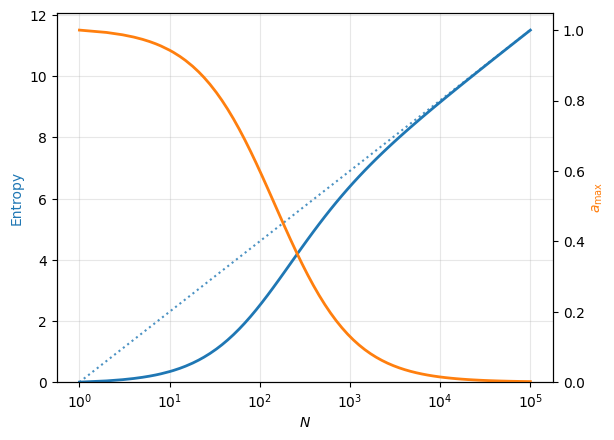

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    z = z - np.max(z)
    e = np.exp(z)
    return e / np.sum(e)

# smooth sampling in exponent
ns = np.linspace(0, 5, 80)
N_list = (10 ** ns).astype(int)

H_list = []
pmax_list = []

for N in N_list:
    z = np.full(N, -2.0)
    z[0] = 3.0

    p = softmax(z)

    H_list.append(-np.sum(p * np.log(p + 1e-12)))
    pmax_list.append(np.max(p))

# ---- plot ----
fig, ax1 = plt.subplots()

# entropy (left axis)
ax1.plot(N_list, H_list, color="#1f77b4", lw=2)
ax1.set_xscale("log", base=10)
ax1.set_xlabel(r"$N$")
ax1.set_ylabel(r"Entropy", color="#1f77b4")
ax1.tick_params(axis='y')

# force baseline alignment
ax1.set_ylim(bottom=0)

# max softmax (right axis)
ax2 = ax1.twinx()
ax2.plot(N_list, pmax_list, color="#ff7f0e", lw=2)
ax2.set_ylabel(r"$a_{\text{max}}$", color="#ff7f0e")
ax2.tick_params(axis='y')

# align baseline
ax2.set_ylim(bottom=0)

# optional: ensure x-limits identical (prevents visual drift)
ax2.set_xscale("log", base=10)
ax2.set_xlim(ax1.get_xlim())

ax1.plot(N_list, np.log(N_list), linestyle=":", color="#1f77b4", lw=1.5,
         label=r"$\log N$", alpha=0.8)

ax1.tick_params(which='minor', bottom=False)

ax1.grid(alpha=0.3)

fig.savefig("entropy_softmax_plot.png", dpi=300, bbox_inches="tight")


plt.show()

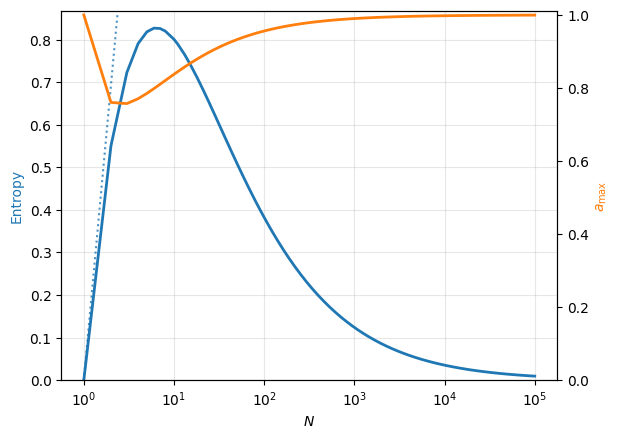

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(z, n=2):
    z = z - np.max(z)
    if n > 1:
        z = z * 1/3 * np.log(n)
    e = np.exp(z)
    return e / np.sum(e)

# smooth sampling in exponent
ns = np.linspace(0, 5, 80)
N_list = (10 ** ns).astype(int)

H_list = []
pmax_list = []

for N in N_list:
    z = np.full(N, -2.0)
    z[0] = 3.0

    p = softmax(z, N)

    H_list.append(-np.sum(p * np.log(p + 1e-12)))
    pmax_list.append(np.max(p))

# ---- plot ----
fig, ax1 = plt.subplots()

# entropy (left axis)
ax1.plot(N_list, H_list, color="#1f77b4", lw=2)
ax1.set_xscale("log", base=10)
ax1.set_xlabel(r"$N$")
ax1.set_ylabel(r"Entropy", color="#1f77b4")
ax1.tick_params(axis='y')

# force baseline alignment
ax1.set_ylim(bottom=0)

# max softmax (right axis)
ax2 = ax1.twinx()
ax2.plot(N_list, pmax_list, color="#ff7f0e", lw=2)
ax2.set_ylabel(r"$a_{\text{max}}$", color="#ff7f0e")
ax2.tick_params(axis='y')

# align baseline
ax2.set_ylim(bottom=0)

# optional: ensure x-limits identical (prevents visual drift)
ax2.set_xscale("log", base=10)
ax2.set_xlim(ax1.get_xlim())

ax1.plot(N_list, np.log(N_list), linestyle=":", color="#1f77b4", lw=1.5,
         label=r"$\log N$", alpha=0.8)

ax1.tick_params(which='minor', bottom=False)

ax1.grid(alpha=0.3)

fig.savefig("entropy_softmax_plot3.png", dpi=300, bbox_inches="tight")


plt.show()

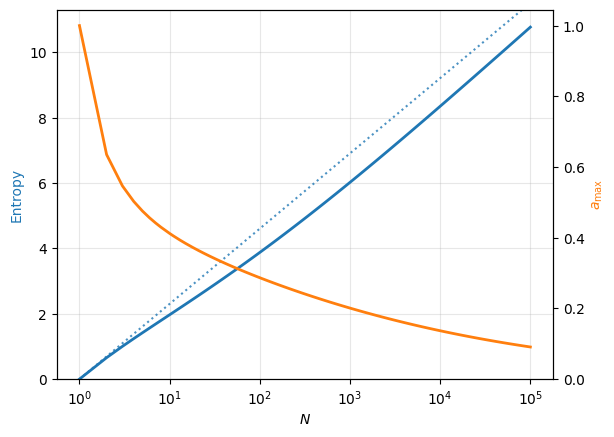

In [180]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    z = z - np.max(z)
    z = z * np.log(len(z)) * 0.16
    e = np.exp(z)
    return e / np.sum(e)

# smooth sampling in exponent
ns = np.linspace(0, 5, 80)
N_list = (10 ** ns).astype(int)

H_list = []
pmax_list = []

for N in N_list:
    z = np.full(N, -2.0)
    z[0] = 3.0

    p = softmax(z)

    H_list.append(-np.sum(p * np.log(p + 1e-12)))
    pmax_list.append(np.max(p))

# ---- plot ----
fig, ax1 = plt.subplots()

# entropy (left axis)
ax1.plot(N_list, H_list, color="#1f77b4", lw=2)
ax1.set_xscale("log", base=10)
ax1.set_xlabel(r"$N$")
ax1.set_ylabel(r"Entropy", color="#1f77b4")
ax1.tick_params(axis='y')

# force baseline alignment
ax1.set_ylim(bottom=0)

# max softmax (right axis)
ax2 = ax1.twinx()
ax2.plot(N_list, pmax_list, color="#ff7f0e", lw=2)
ax2.set_ylabel(r"$a_{\text{max}}$", color="#ff7f0e")
ax2.tick_params(axis='y')

# align baseline
ax2.set_ylim(bottom=0)

# optional: ensure x-limits identical (prevents visual drift)
ax2.set_xscale("log", base=10)
ax2.set_xlim(ax1.get_xlim())

ax1.plot(N_list, np.log(N_list), linestyle=":", color="#1f77b4", lw=1.5,
         label=r"$\log N$", alpha=0.8)

ax1.tick_params(which='minor', bottom=False)

ax1.grid(alpha=0.3)



plt.show()

In [20]:
def softmax(z):
    z = z - np.max(z)
    e = np.exp(z)
    return e / np.sum(e)

In [25]:
b = [-0.5, 0.7, 1.2, 2.1]
softmax(b)

array([0.04299632, 0.14275282, 0.23535961, 0.57889124])